# Comparative Analysis: LLM-Generated Ferritic/Martensitic Steel Data

This notebook brings together the four cleaned datasets (from `01_grok_analysis.ipynb`,
`02_gemini_analysis.ipynb`, `03_claude_analysis.ipynb`, and `04_chatgpt_analysis.ipynb`)
and compares them side by side, one plot type at a time, to see which models captured
real metallurgical behavior and which didn't.

Run the four individual notebooks first (or make sure the `cleaned_*.csv` files are
already present in this folder) before running this one.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


## 1. Load all four cleaned datasets


In [2]:
files = {
    'Grok': '../data/cleaned/cleaned_grok.csv',
    'Gemini': '../data/cleaned/cleaned_gemini.csv',
    'Claude': '../data/cleaned/cleaned_claude.csv',
    'ChatGPT': '../data/cleaned/cleaned_chatgpt.csv'
}

dfs = {}
for name, filepath in files.items():
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)

        # make sure phase columns are numeric even if they were read in as text
        for col in df.columns:
            if 'Phase' in col or 'Vol_%' in col:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        dfs[name] = df
    else:
        print(f"Warning: {name} file not found ({filepath})")

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
custom_palette = {"Ferritic": "#2b8cbe", "Martensitic": "#d73027"}


## 2. Comparison plots

Each plot below is arranged as a 2x2 grid, one panel per model, so the same physical
relationship can be checked across all four at once.


In [3]:
def plot_comparative_grid(plot_func, fig_title):
    """Creates a 2x2 grid of plots, one for each LLM."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, (name, df) in enumerate(dfs.items()):
        if i < 4:
            ax = axes[i]
            palette = custom_palette.copy()
            if 'Alloy_Type' in df.columns:
                for cls in df['Alloy_Type'].unique():
                    if cls not in palette:
                        palette[cls] = "#95a5a6"

            plot_func(df, ax, name, palette)
            ax.set_title(f"{name}", fontweight='bold', fontsize=14)
            ax.grid(True, alpha=0.3)

    plt.suptitle(fig_title, fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


### Correlation matrix

A first sanity check: do the properties in each dataset relate to each other the way
real steel properties should (e.g. hardness and carbon content moving together, yield
strength and elongation moving oppositely)?


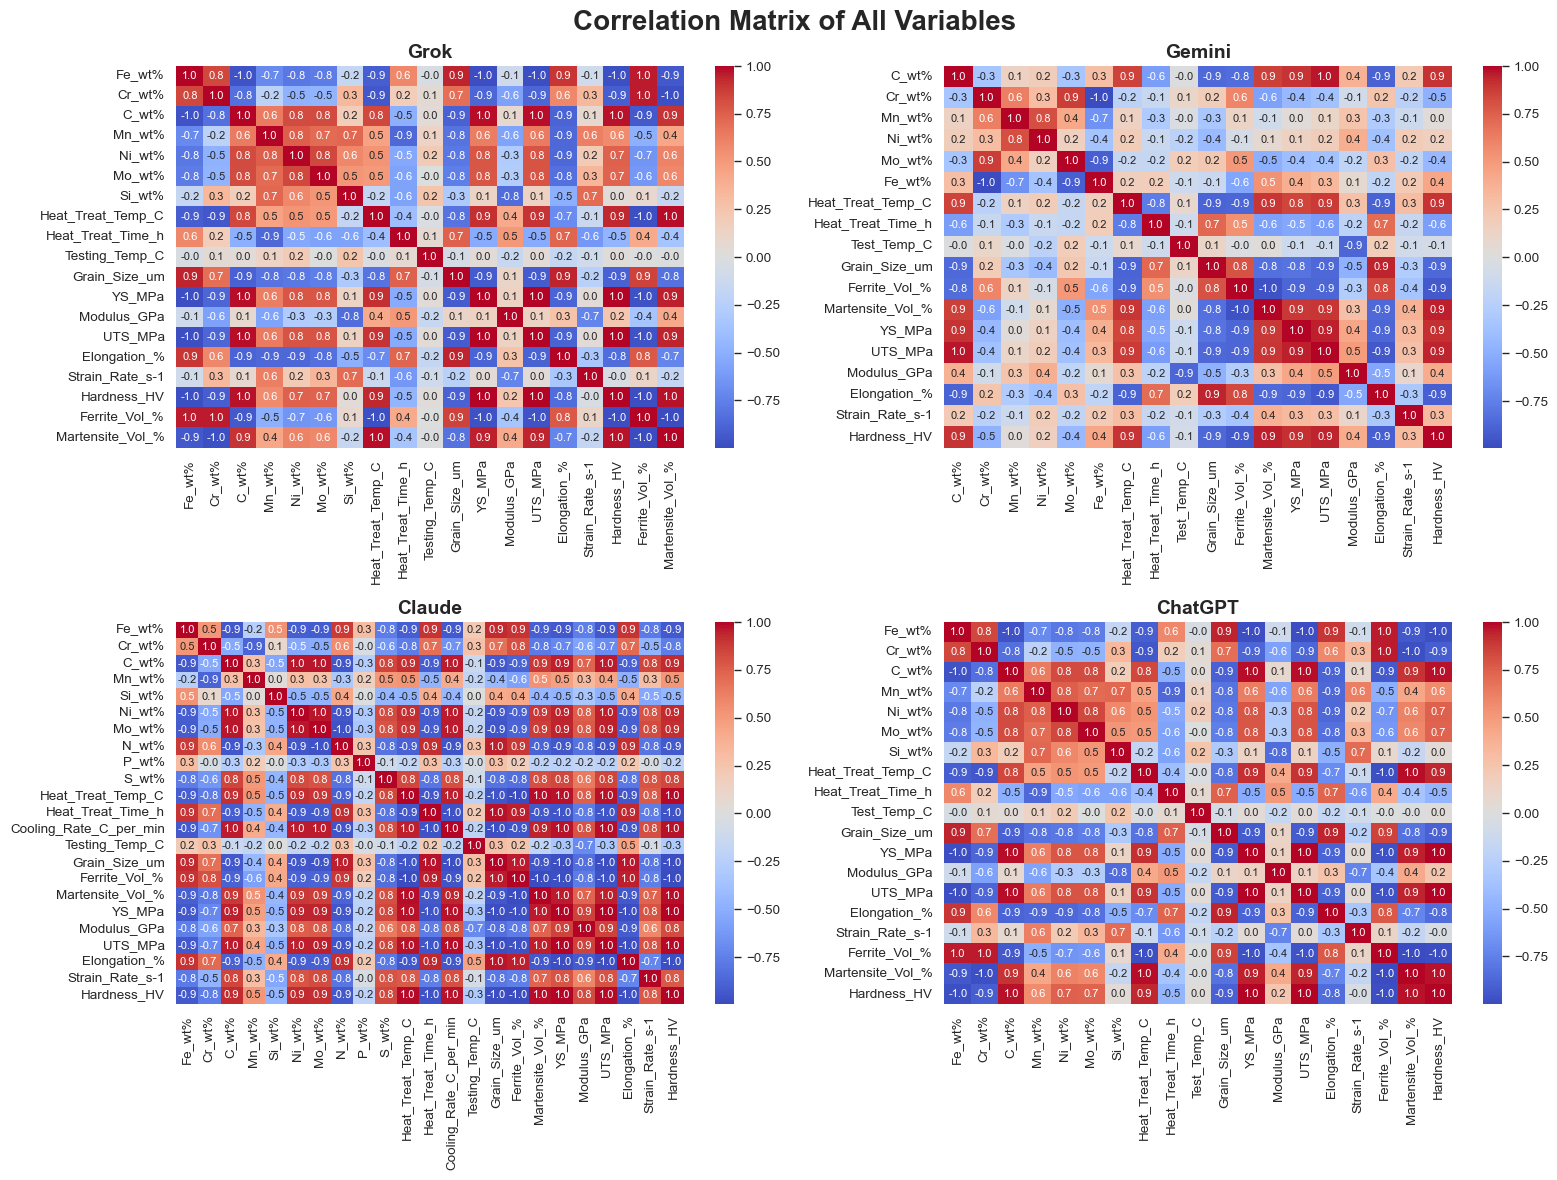

In [4]:
def plot_corr(df, ax, name, palette):
    numeric_df = df.select_dtypes(include=[np.number])
    if 'ID' in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=['ID'])
    sns.heatmap(numeric_df.corr(), annot=True, fmt=".1f", cmap="coolwarm", center=0,
                cbar=True, ax=ax, annot_kws={"size": 8})

plot_comparative_grid(plot_corr, "Correlation Matrix of All Variables")


### Hall-Petch relationship (yield strength vs. grain size)

Finer grains should give higher strength (\u03c3_y \u221d d^-0.5).


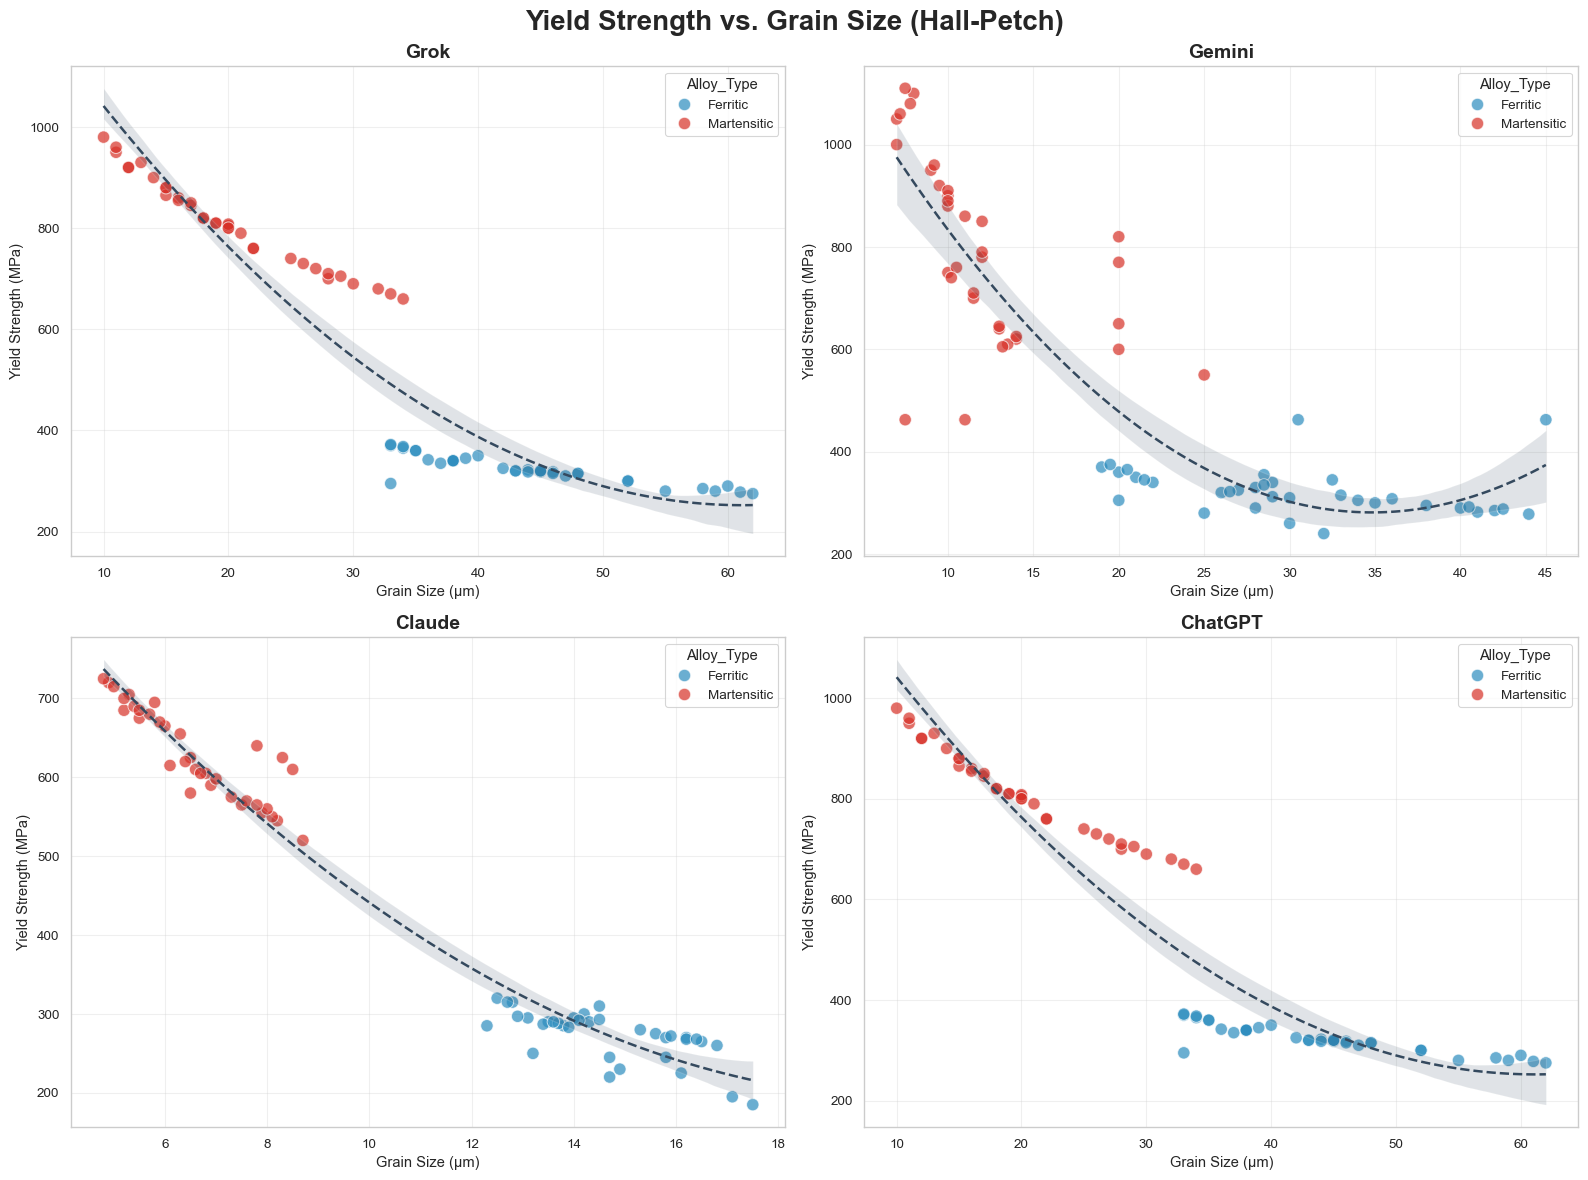

In [5]:
def plot_hall_petch(df, ax, name, palette):
    if 'Grain_Size_um' in df.columns:
        sns.scatterplot(data=df, x='Grain_Size_um', y='YS_MPa', hue='Alloy_Type',
                        palette=palette, s=80, alpha=0.7, ax=ax)
        sns.regplot(data=df, x='Grain_Size_um', y='YS_MPa', scatter=False,
                    order=2, color='#34495e', line_kws={'linestyle':'--'}, ax=ax)
        ax.set_xlabel('Grain Size (\u00b5m)')
        ax.set_ylabel('Yield Strength (MPa)')

plot_comparative_grid(plot_hall_petch, "Yield Strength vs. Grain Size (Hall-Petch)")


### Strength-ductility trade-off (yield strength vs. elongation)

Higher-strength martensite should trade off against ductility compared to ferrite.


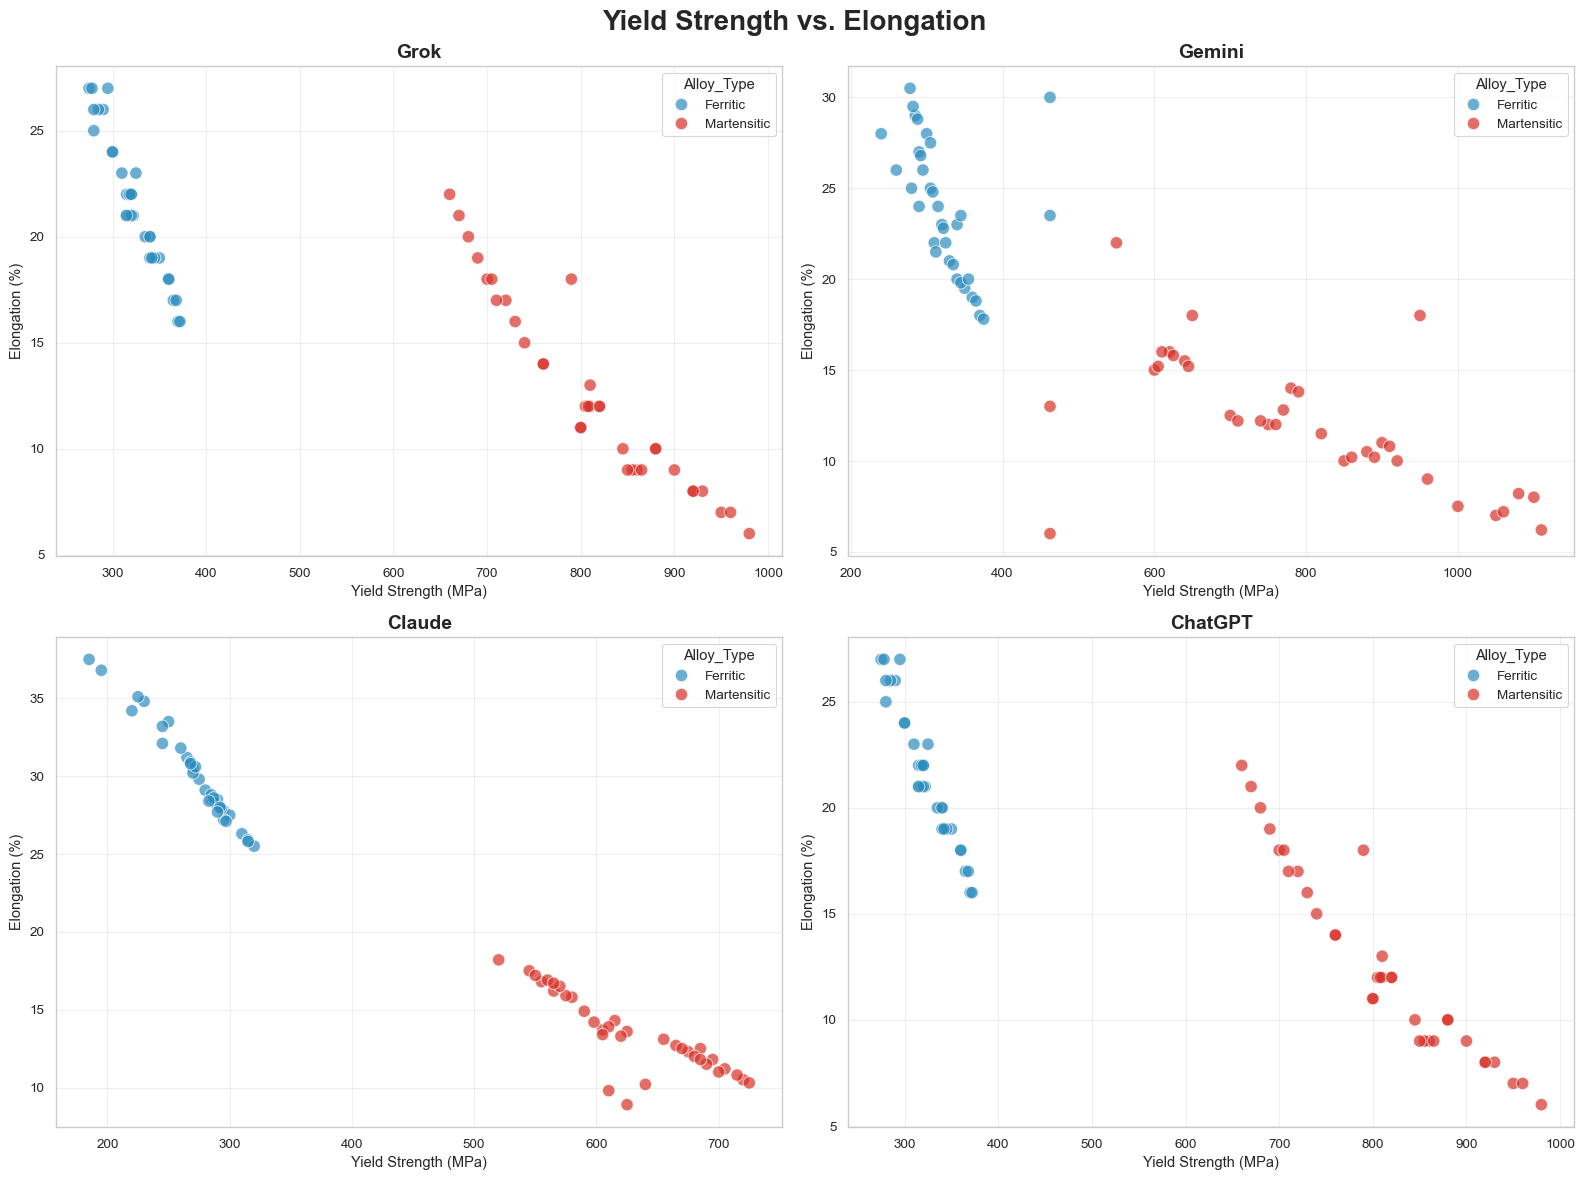

In [6]:
def plot_banana(df, ax, name, palette):
    sns.scatterplot(data=df, x='YS_MPa', y='Elongation_%', hue='Alloy_Type',
                    palette=palette, s=80, alpha=0.7, ax=ax)
    ax.set_xlabel('Yield Strength (MPa)')
    ax.set_ylabel('Elongation (%)')

plot_comparative_grid(plot_banana, "Yield Strength vs. Elongation")


### Solid-solution hardening (hardness vs. carbon content)


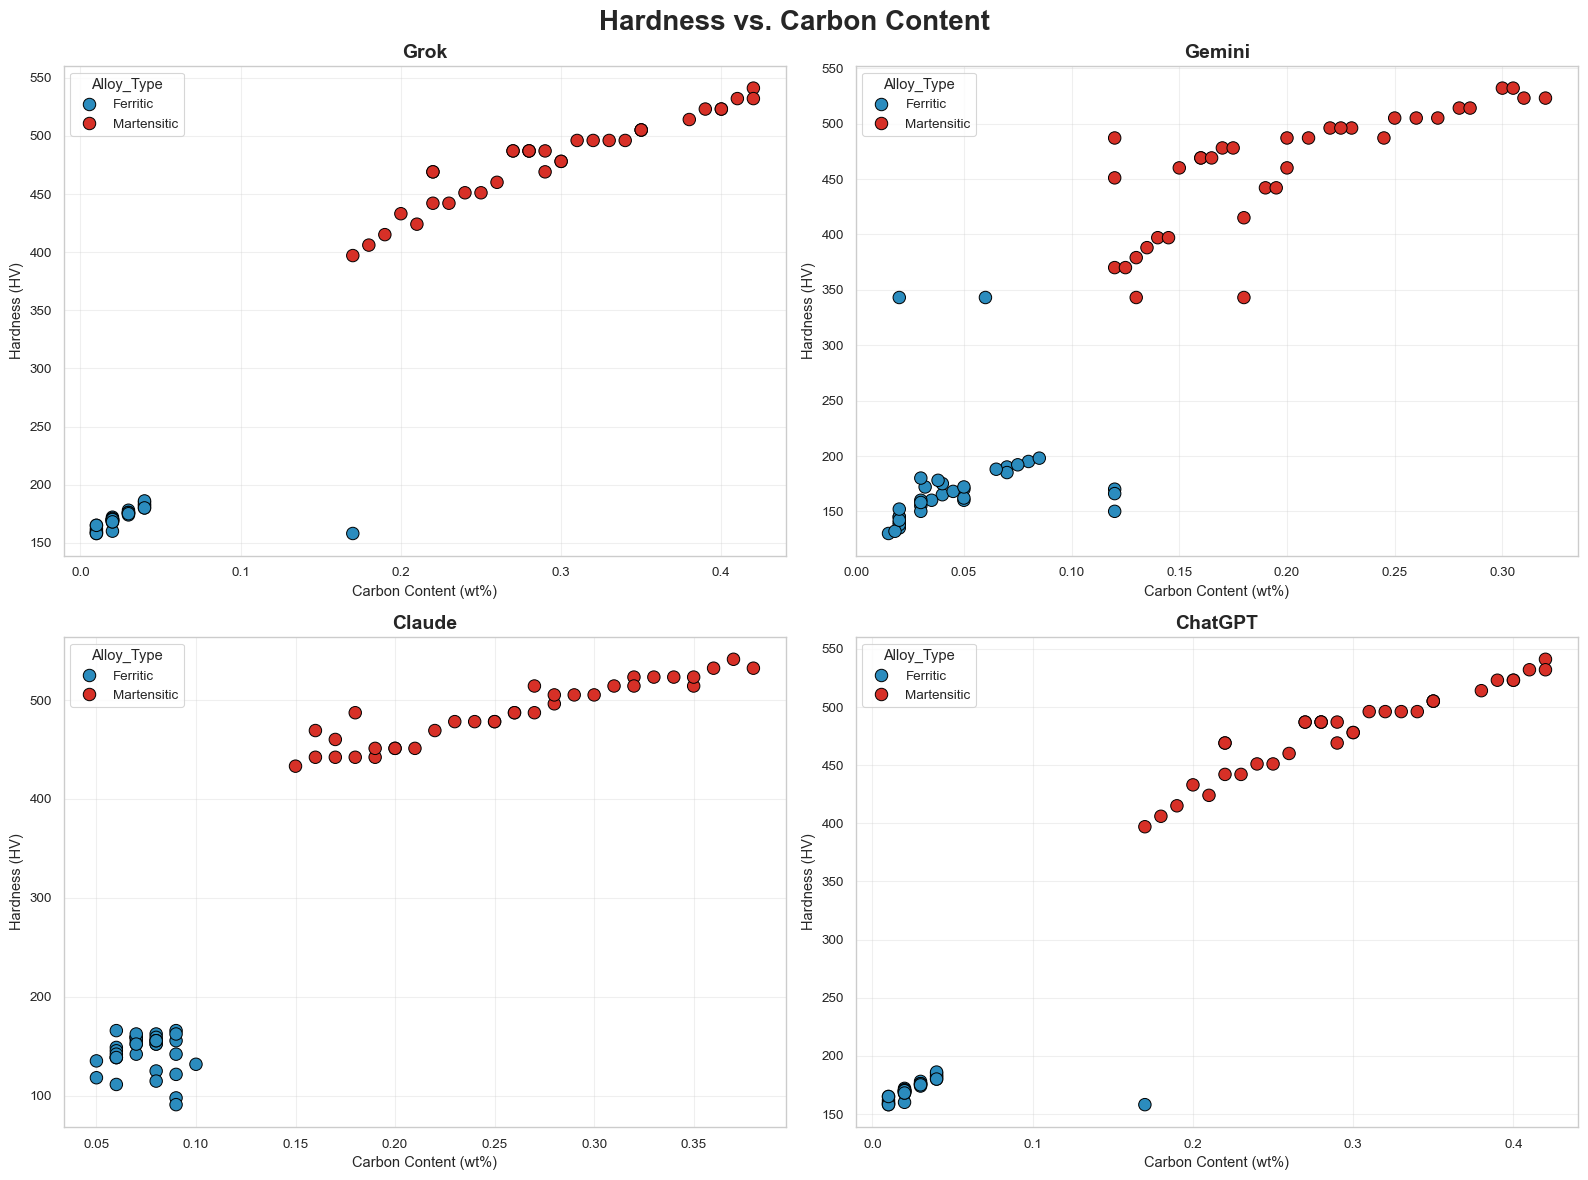

In [7]:
def plot_carbon(df, ax, name, palette):
    if 'C_wt%' in df.columns:
        sns.scatterplot(data=df, x='C_wt%', y='Hardness_HV', hue='Alloy_Type',
                        palette=palette, s=80, edgecolor='black', ax=ax)
        ax.set_xlabel('Carbon Content (wt%)')
        ax.set_ylabel('Hardness (HV)')

plot_comparative_grid(plot_carbon, "Hardness vs. Carbon Content")


### Internal consistency check (UTS vs. hardness)

UTS and hardness both measure resistance to deformation, so they should be linearly
related.


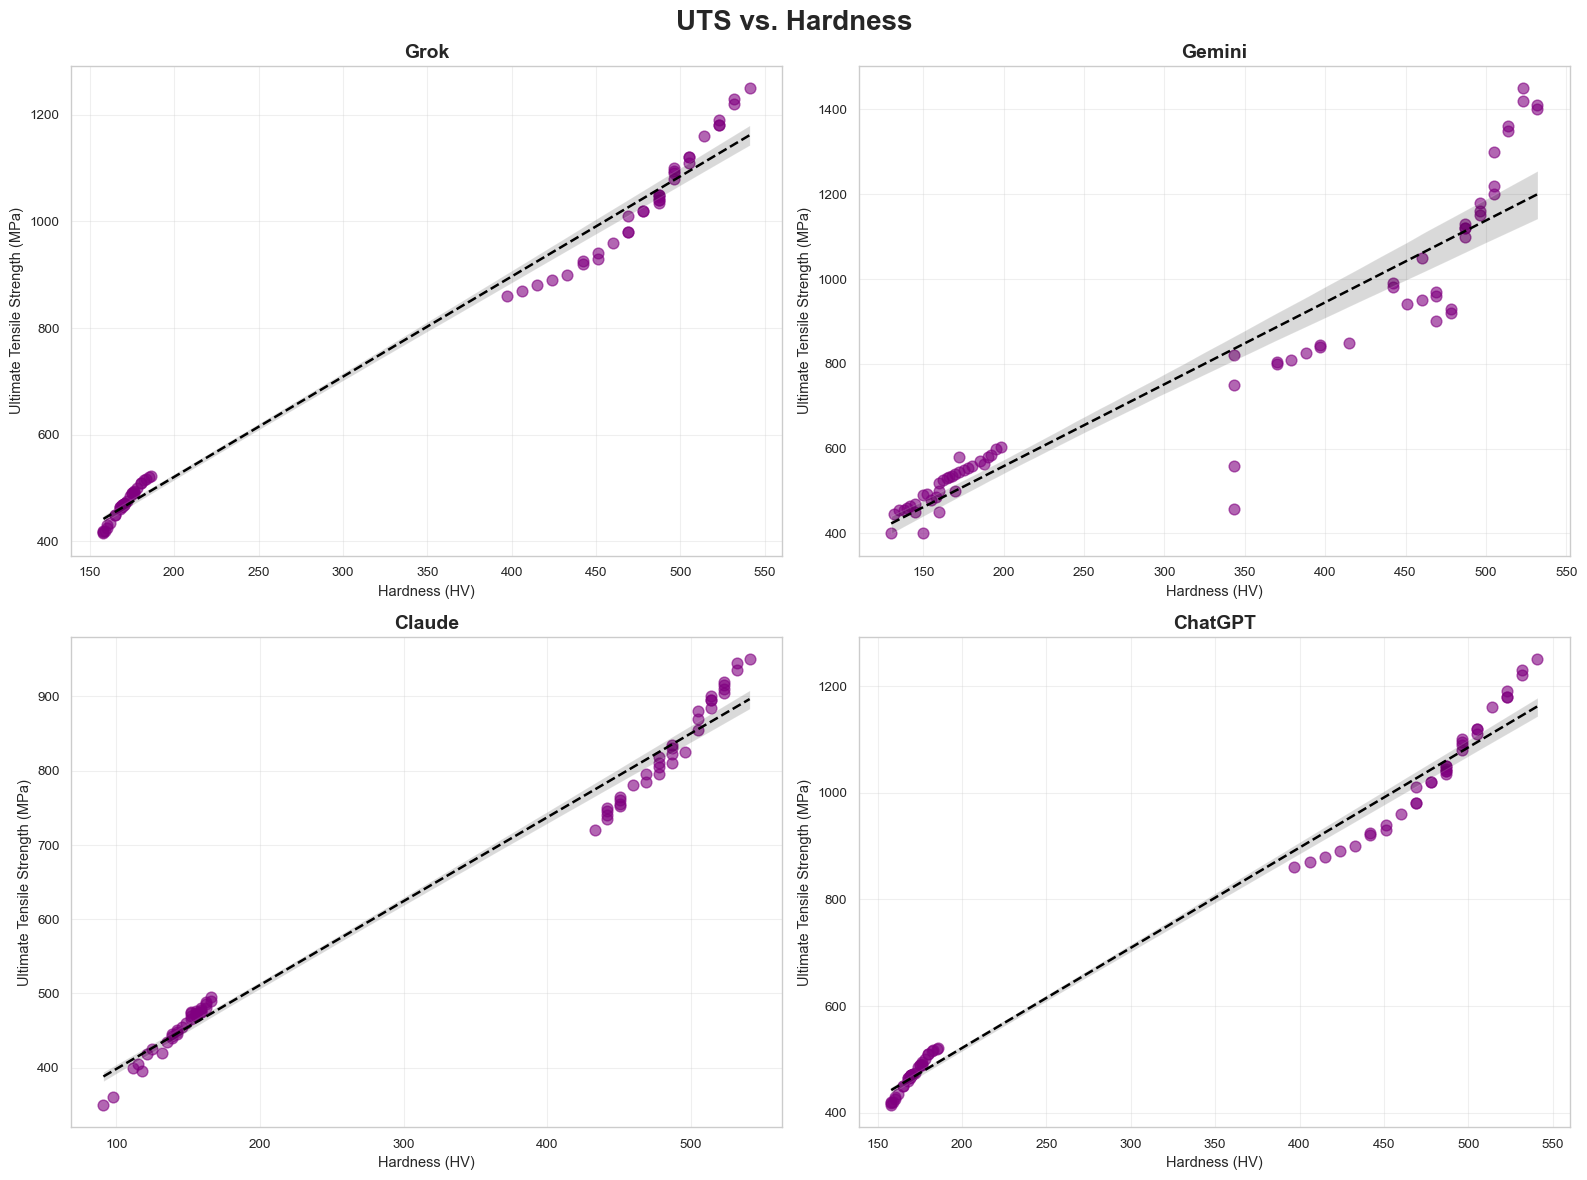

In [8]:
def plot_consistency(df, ax, name, palette):
    sns.regplot(data=df, x='Hardness_HV', y='UTS_MPa',
                scatter_kws={'s': 60, 'alpha': 0.6, 'color':'purple'},
                line_kws={'color':'black', 'linestyle':'--'}, ax=ax)
    ax.set_xlabel('Hardness (HV)')
    ax.set_ylabel('Ultimate Tensile Strength (MPa)')

plot_comparative_grid(plot_consistency, "UTS vs. Hardness")


### Phase fraction effect (yield strength vs. ferrite fraction)

Strength should drop as the softer ferrite phase fraction increases.


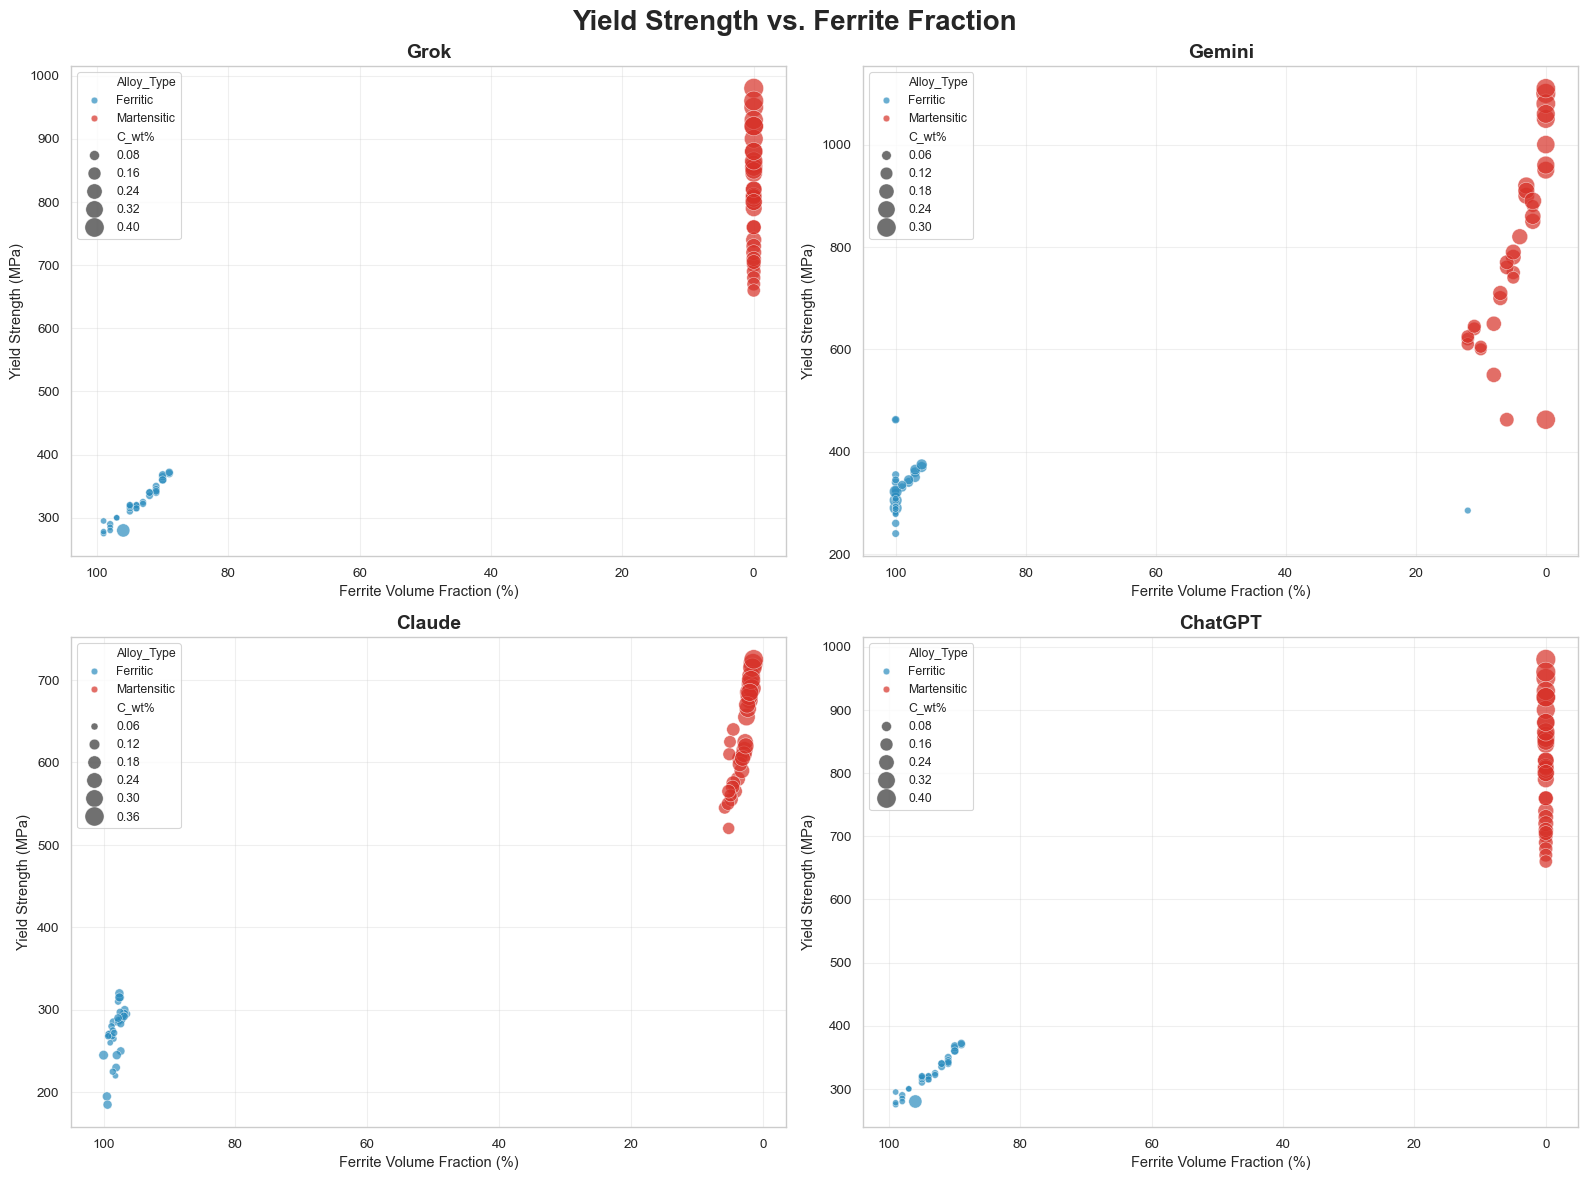

In [9]:
def plot_phase(df, ax, name, palette):
    if 'Ferrite_Vol_%' in df.columns and 'C_wt%' in df.columns:
        sns.scatterplot(data=df, x='Ferrite_Vol_%', y='YS_MPa', hue='Alloy_Type',
                        size='C_wt%', sizes=(20, 200), palette=palette,
                        alpha=0.7, ax=ax)
        ax.invert_xaxis()
        ax.set_xlabel('Ferrite Volume Fraction (%)')
        ax.set_ylabel('Yield Strength (MPa)')
        ax.legend(loc='upper left', fontsize='small')

plot_comparative_grid(plot_phase, "Yield Strength vs. Ferrite Fraction")


### Processing-property link (yield strength vs. heat treatment temperature)

Higher annealing temperatures should soften ferrite, while quenching should harden
martensite.


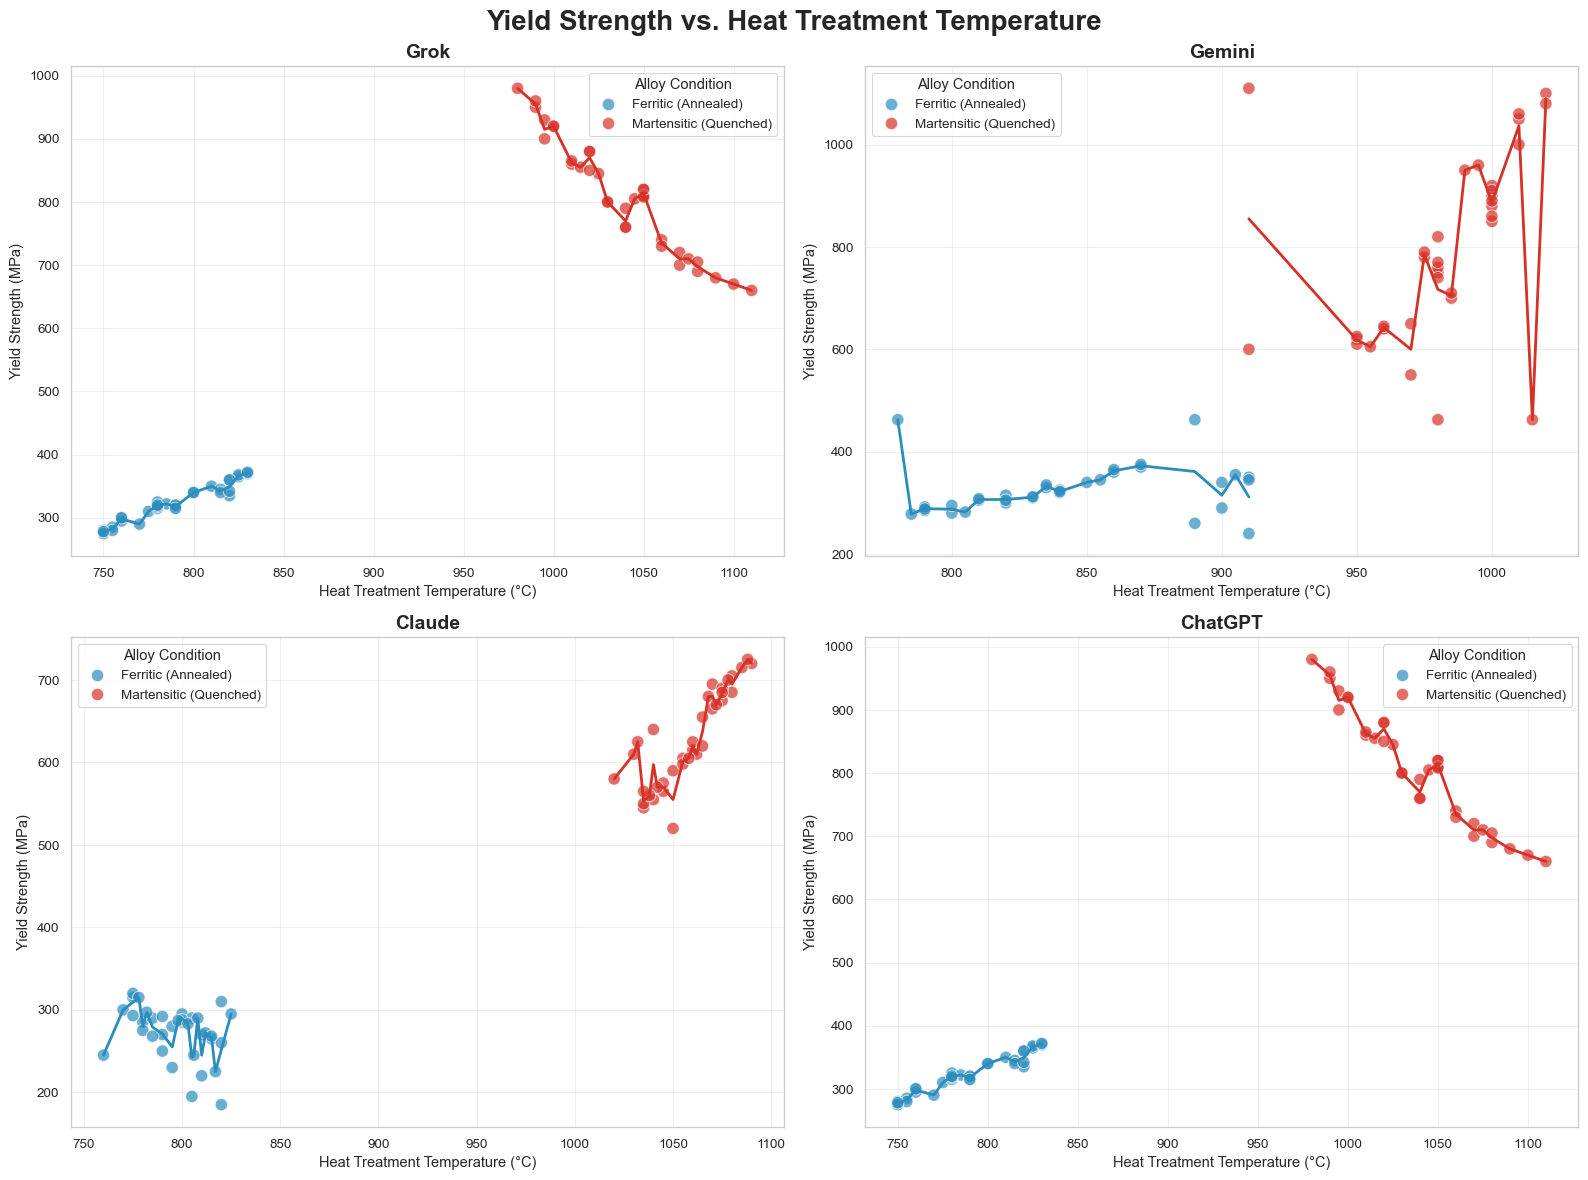

In [10]:
def plot_heat_treat(df, ax, name, palette):
    if 'Heat_Treat_Temp_C' in df.columns:
        df['P_Label'] = df['Alloy_Type'].map({
            'Ferritic': 'Ferritic (Annealed)', 'Martensitic': 'Martensitic (Quenched)'
        }).fillna(df['Alloy_Type'])

        sns.scatterplot(data=df, x='Heat_Treat_Temp_C', y='YS_MPa', hue='P_Label',
                        palette={'Ferritic (Annealed)': '#2b8cbe', 'Martensitic (Quenched)': '#d73027'},
                        s=80, alpha=0.7, ax=ax)
        sns.lineplot(data=df, x='Heat_Treat_Temp_C', y='YS_MPa', hue='P_Label',
                     palette={'Ferritic (Annealed)': '#2b8cbe', 'Martensitic (Quenched)': '#d73027'},
                     marker=None, linewidth=2, errorbar=None, ax=ax, legend=False)

        ax.set_xlabel('Heat Treatment Temperature (\u00b0C)')
        ax.set_ylabel('Yield Strength (MPa)')
        ax.legend(title='Alloy Condition')

plot_comparative_grid(plot_heat_treat, "Yield Strength vs. Heat Treatment Temperature")


### Strength distribution by alloy type (violin plot)


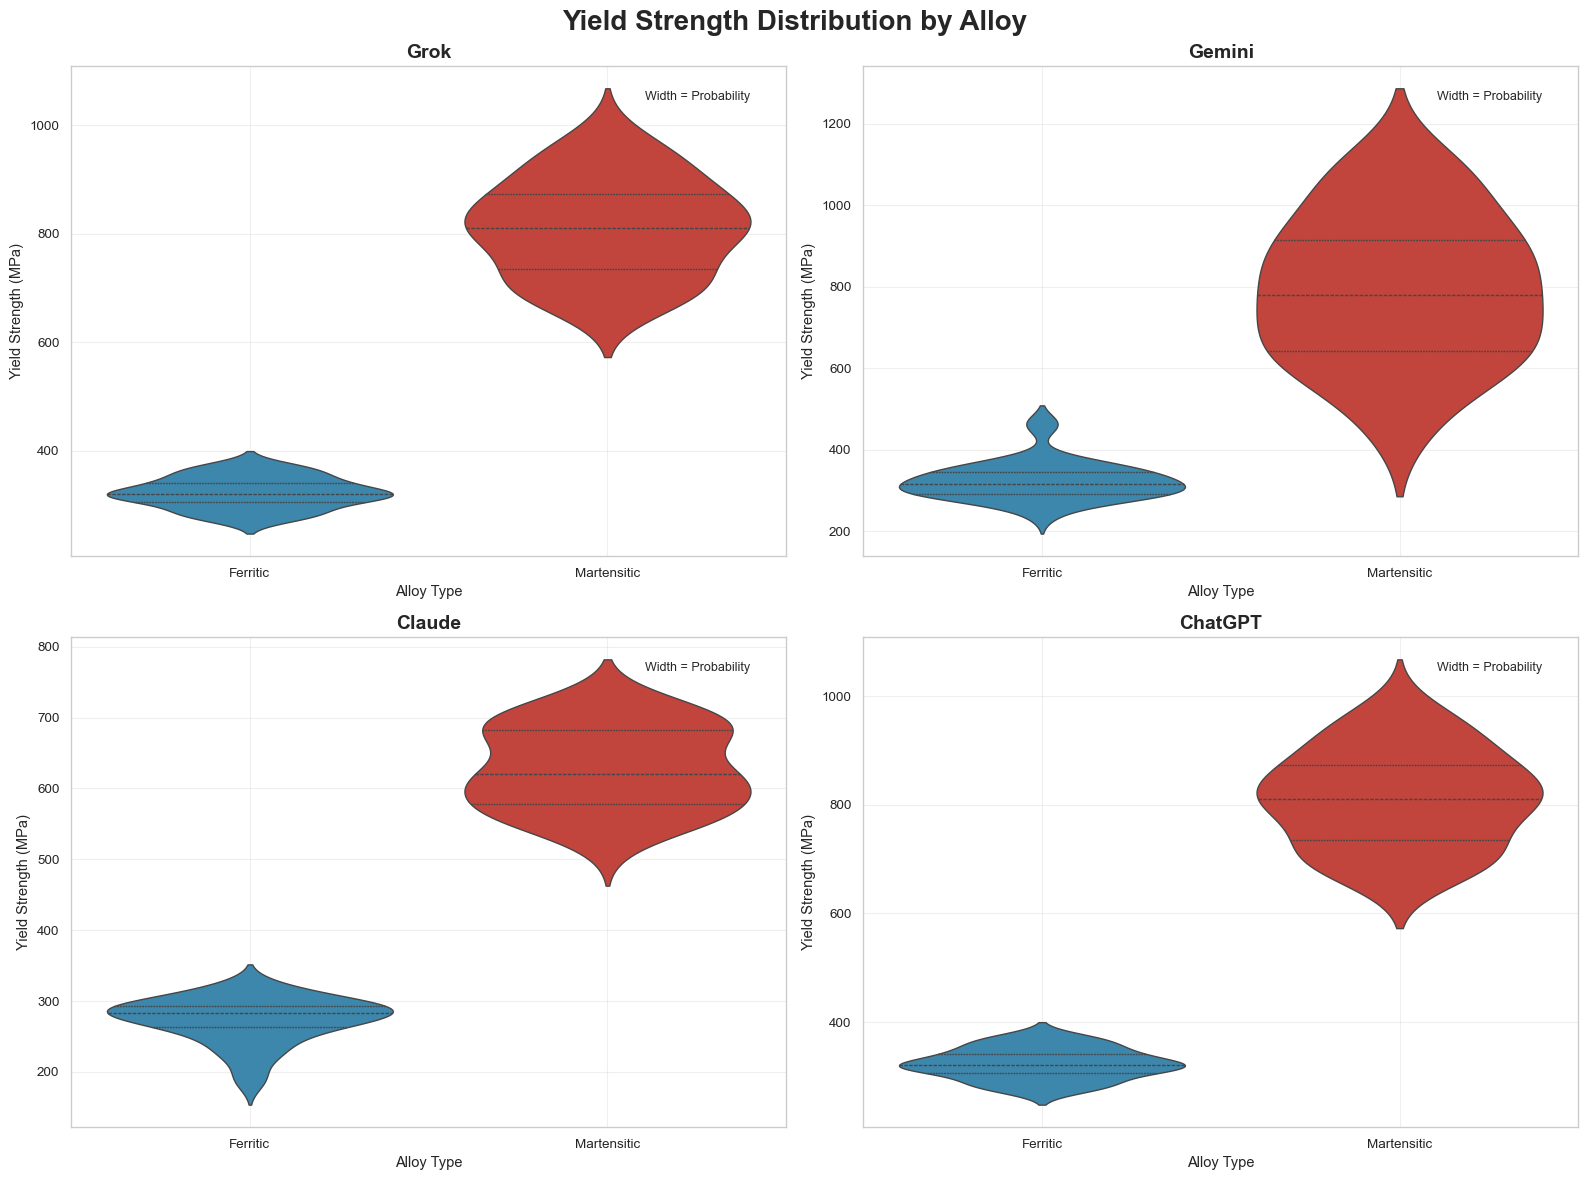

In [11]:
def plot_violin(df, ax, name, palette):
    sns.violinplot(data=df, x='Alloy_Type', y='YS_MPa', hue='Alloy_Type',
                   palette=palette, inner="quartile", dodge=False, ax=ax, legend=False)
    ax.set_xlabel('Alloy Type')
    ax.set_ylabel('Yield Strength (MPa)')
    ax.text(0.95, 0.95, 'Width = Probability', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, bbox=dict(boxstyle="round", fc="white", alpha=0.8))

plot_comparative_grid(plot_violin, "Yield Strength Distribution by Alloy")


## 3. Comparison with literature data

The four AI-generated datasets were also compared against real experimental data
collected from 13 peer-reviewed papers on Ferritic and Martensitic stainless steels.
The literature values ranged from 310 to 1265 MPa for yield strength, and 2.7% to 26%
for elongation.

The Claude and Gemini datasets stayed closest to these literature ranges, correctly
assigning higher strength to martensitic grades. The Grok dataset deviated the most,
including elongation values above 40%, which fall well outside the reported limits for
this alloy class.

The literature data also showed a clear processing-property relationship: annealed
samples were consistently softer and more ductile than quenched samples. Claude was the
only model to reproduce this relationship clearly, with higher heat treatment
temperatures correlating with reduced strength. ChatGPT and Grok showed no clear
relationship between heat treatment and the final mechanical properties.

One notable difference is data completeness: the real literature dataset had large,
systematic gaps (hardness alone was missing in roughly 58% of data points), while all
four AI-generated datasets were much cleaner, containing only the ~15% random missing
values that were explicitly requested in the generation prompt. This made the synthetic
data easier to analyze, but it doesn't reflect how messy real experimental data actually
tends to be.


## Conclusion

Across all eight comparisons, **Claude and Gemini** were the most reliable of the four
models: they reproduced the Hall-Petch relationship, the strength-ductility trade-off,
and the expected effect of heat treatment on mechanical properties, and their value
ranges matched the literature data reasonably well.

**ChatGPT** produced numerically valid data (values stayed within plausible bounds) but
failed to encode the underlying physical relationships, resulting in scattered or
step-like plots rather than smooth physical trends.

**Grok** performed the worst overall, with several physically implausible data points
(e.g. simultaneously high strength and high elongation, elongation values exceeding
literature limits) and little evidence that the generated properties were coupled to
each other in a physically meaningful way.

The overall takeaway: LLMs can be useful for quickly generating structured, schema-
consistent data, but none of them can currently be trusted to simulate accurate physical
behavior without validation. Any AI-generated dataset intended for real analysis should
be checked against experimental literature before being used.
